# Analyse business

Analysons la performance commerciale à partir des tables analytiques construites dans DuckDB.



In [1]:
from pathlib import Path

import duckdb
import pandas as pd


CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATABASE_FILE = (
    PROJECT_ROOT
    / "data"
    / "warehouse"
    / "customer_value_radar.duckdb"
)

connection = duckdb.connect(
    str(DATABASE_FILE),
    read_only=True
)

print("Connexion DuckDB : OK")

Connexion DuckDB : OK


In [2]:
business_kpis = connection.sql(
    """
    SELECT

        ROUND(
            SUM(gross_product_sales_value),
            2
        ) AS gross_product_sales,

        ROUND(
            SUM(product_cancellation_value),
            2
        ) AS product_cancellations,

        ROUND(
            SUM(net_product_sales_value),
            2
        ) AS net_product_sales,

        SUM(
            CASE
                WHEN has_product_sale THEN 1
                ELSE 0
            END
        ) AS purchase_invoices,

        SUM(
            CASE
                WHEN has_product_cancellation THEN 1
                ELSE 0
            END
        ) AS cancellation_invoices,

        COUNT(
            DISTINCT CASE
                WHEN has_product_sale
                    AND customer_id IS NOT NULL
                THEN customer_id
            END
        ) AS identified_purchasing_customers,

        ROUND(
            SUM(gross_product_sales_value)
            /
            NULLIF(
                SUM(
                    CASE
                        WHEN has_product_sale THEN 1
                        ELSE 0
                    END
                ),
                0
            ),
            2
        ) AS average_gross_order_value

    FROM fact_orders
    """
).df()

display(business_kpis)

,gross_product_sales,product_cancellations,net_product_sales,purchase_invoices,cancellation_invoices,identified_purchasing_customers,average_gross_order_value
0,19700954.46,-719692.94,18981261.52,39516.0,7406.0,5852,498.56


In [3]:
kpi_display = (
    business_kpis
    .T
    .reset_index()
)

kpi_display.columns = [
    "KPI",
    "Value"
]

display(kpi_display)

,KPI,Value
0,gross_product_sales,19700954.46
1,product_cancellations,-719692.94
2,net_product_sales,18981261.52
3,purchase_invoices,39516.00
4,cancellation_invoices,7406.00
5,identified_purchasing_customers,5852.00
6,average_gross_order_value,498.56


In [4]:
monthly_performance = connection.sql(
    """
    SELECT

        DATE_TRUNC(
            'month',
            order_datetime
        ) AS month,

        ROUND(
            SUM(gross_product_sales_value),
            2
        ) AS gross_product_sales,

        ROUND(
            SUM(product_cancellation_value),
            2
        ) AS product_cancellations,

        ROUND(
            SUM(net_product_sales_value),
            2
        ) AS net_product_sales,

        SUM(
            CASE
                WHEN has_product_sale THEN 1
                ELSE 0
            END
        ) AS purchase_invoices,

        COUNT(
            DISTINCT CASE
                WHEN has_product_sale
                    AND customer_id IS NOT NULL
                THEN customer_id
            END
        ) AS active_identified_customers

    FROM fact_orders

    GROUP BY 1

    ORDER BY 1
    """
).df()

display(monthly_performance)

,month,gross_product_sales,product_cancellations,net_product_sales,purchase_invoices,active_identified_customers
0,2009-12-01,801102.97,-19561.28,781541.69,1666.0,951
1,2010-01-01,613850.81,-7465.63,606385.18,1049.0,701
2,2010-02-01,539744.69,-12584.39,527160.30,1189.0,771
3,2010-03-01,764333.85,-9657.20,754676.65,1647.0,1051
4,2010-04-01,648993.82,-10025.26,638968.56,1435.0,939
5,2010-05-01,645645.39,-37294.14,608351.25,1484.0,965
6,2010-06-01,699316.02,-26380.61,672935.41,1612.0,1034
7,2010-07-01,634896.99,-17132.73,617764.26,1507.0,924
8,2010-08-01,676060.72,-12418.65,663642.07,1402.0,910
9,2010-09-01,871878.34,-27777.97,844100.37,1789.0,1136


## EDA Performance commerciale

évolution des principaux indicateurs commerciaux

In [6]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


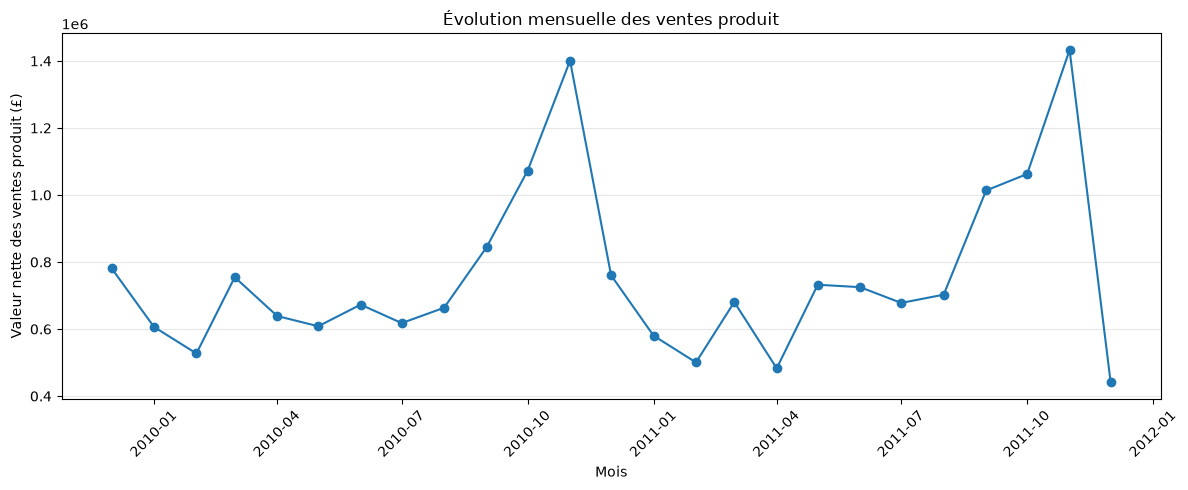

In [7]:
# Evolution mensuelle des ventes produit

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_performance["month"],
    monthly_performance["net_product_sales"],
    marker="o"
)

plt.title(
    "Évolution mensuelle des ventes produit"
)

plt.xlabel("Mois")
plt.ylabel("Valeur nette des ventes produit (£)")

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

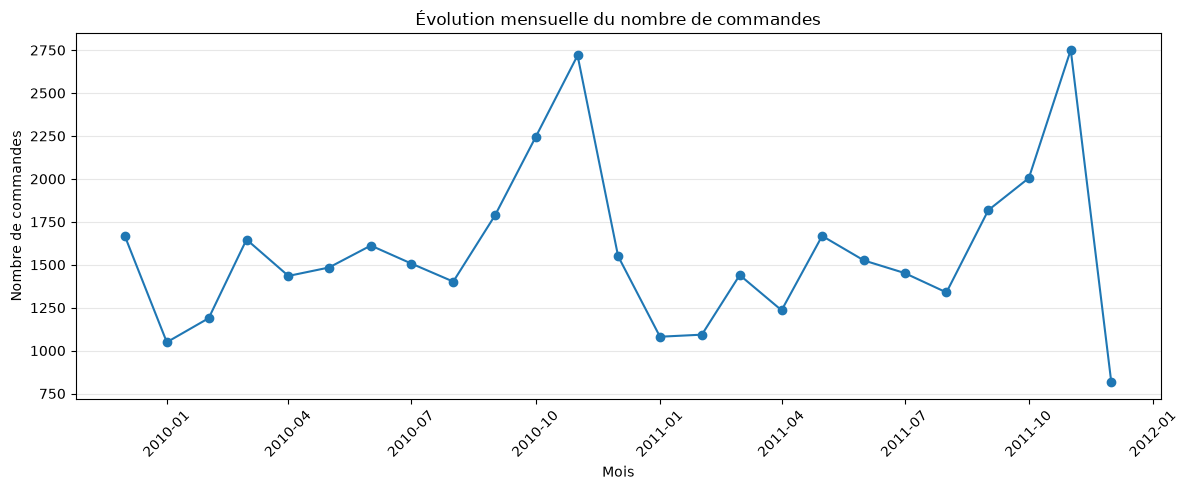

In [8]:
# Evolution mensuelle des commandes

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_performance["month"],
    monthly_performance["purchase_invoices"],
    marker="o"
)

plt.title(
    "Évolution mensuelle du nombre de commandes"
)

plt.xlabel("Mois")
plt.ylabel("Nombre de commandes")

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()



- Les ventes produit et le nombre de commandes suivent une évolution mensuelle assez similaire.
- Une hausse de l'activité apparaît à l'approche de la fin d'année.
- Les niveaux les plus élevés sont observés autour d'octobre-novembre 2010 et 2011.
- Les périodes de fortes ventes correspondent aussi à un nombre plus important de commandes.
- Cela suggère une saisonnalité de l'activité.
- Le dataset s'arrête au 9 décembre 2011 : ce mois est donc incomplet.

In [9]:
# Calcul du panier moyen mensuel

monthly_performance["average_order_value"] = (
    monthly_performance["gross_product_sales"]
    / monthly_performance["purchase_invoices"]
)

display(
    monthly_performance[
        [
            "month",
            "gross_product_sales",
            "purchase_invoices",
            "average_order_value"
        ]
    ]
)

,month,gross_product_sales,purchase_invoices,average_order_value
0,2009-12-01,801102.97,1666.0,480.854124
1,2010-01-01,613850.81,1049.0,585.177131
2,2010-02-01,539744.69,1189.0,453.948436
3,2010-03-01,764333.85,1647.0,464.076412
4,2010-04-01,648993.82,1435.0,452.260502
5,2010-05-01,645645.39,1484.0,435.071018
6,2010-06-01,699316.02,1612.0,433.818871
7,2010-07-01,634896.99,1507.0,421.298600
8,2010-08-01,676060.72,1402.0,482.211641
9,2010-09-01,871878.34,1789.0,487.355137


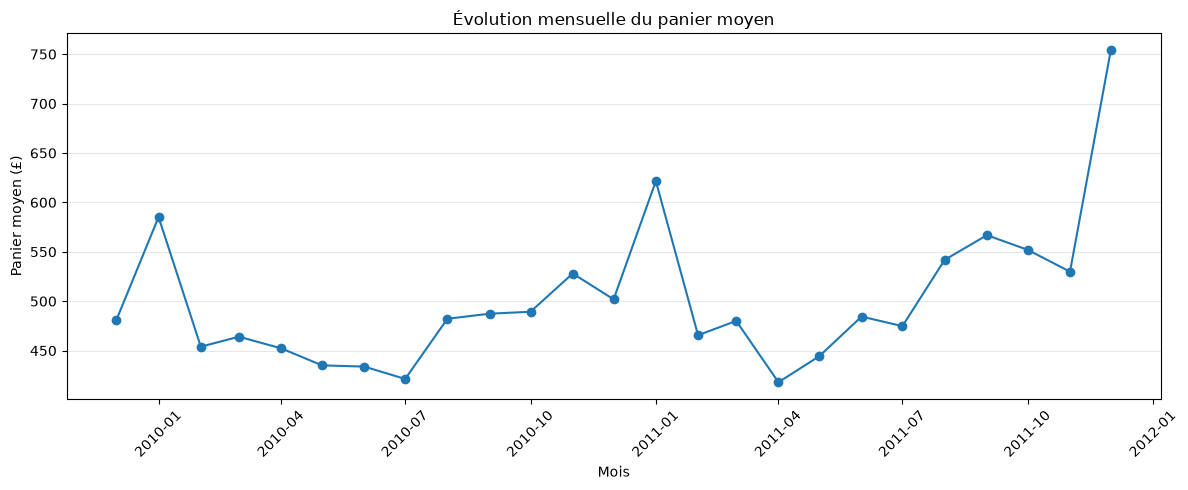

In [10]:
# Evolution mensuelle du panier moyen

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_performance["month"],
    monthly_performance["average_order_value"],
    marker="o"
)

plt.title("Évolution mensuelle du panier moyen")

plt.xlabel("Mois")
plt.ylabel("Panier moyen (£)")

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

### Analyse du panier moyen

- Les ventes peuvent augmenter pour deux raisons principales :
  - davantage de commandes 
  - un panier moyen plus élevé.
- L'analyse du panier moyen permet de distinguer ces deux effets.
- On compare donc :
  - la valeur des ventes 
  - le nombre de commandes 
  - le panier moyen.

- Le panier moyen varie globalement entre environ £420 et £620 sur la majorité de la période.
- Le niveau du panier moyen n'est donc pas constant dans le temps.
- Une progression apparaît au second semestre 2011.
- Les fortes ventes de fin d'année semblent être expliquées par :
  - un nombre de commandes plus élevé ;
  - un panier moyen relativement plus important.
- Le pic de décembre 2011 doit être interprété avec prudence.
- Le dataset s'arrête au 9 décembre 2011 : le mois est incomplet et ne représente pas un mois de décembre entier.

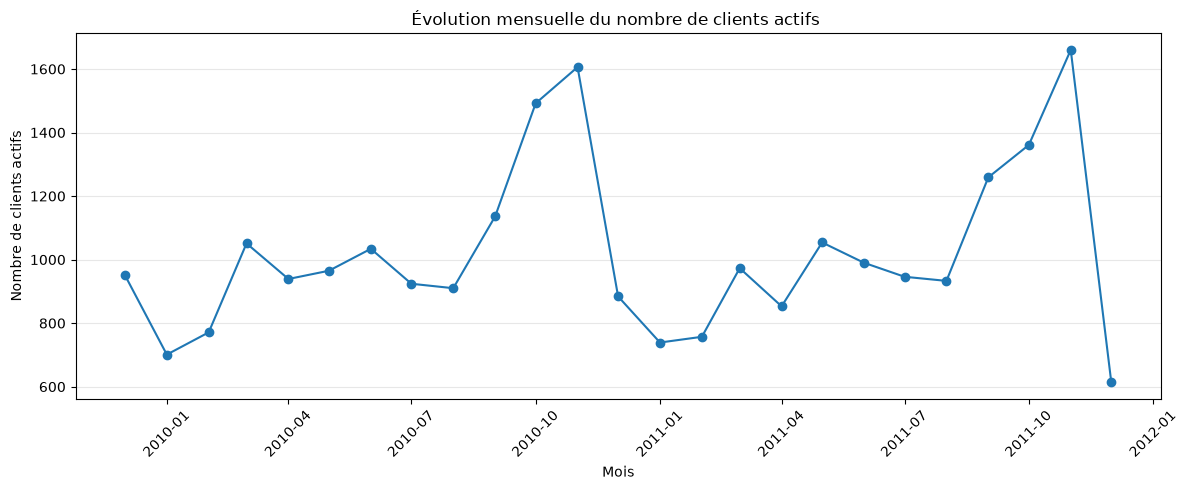

In [12]:
# Evolution mensuelle du nombre de clients actifs 

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_performance["month"],
    monthly_performance["active_identified_customers"],
    marker="o"
)

plt.title(
    "Évolution mensuelle du nombre de clients actifs "
)

plt.xlabel("Mois")
plt.ylabel("Nombre de clients actifs")

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

### Les clients actifs

- Le nombre de clients actifs varie fortement
- Une hausse nette apparaît à partir de la fin de l'été et au début de l'automne.
- Les niveaux les plus élevés sont observés autour d'octobre-novembre 2010 et 2011.
- Cette évolution est proche de celle du nombre de commandes.
- Les périodes de fortes ventes correspondent donc aussi à un nombre plus important de clients actifs.
- La croissance de fin d'année semble être portée par plusieurs facteurs :
  - davantage de clients actifs 
  - davantage de commandes 
  - un panier moyen plus élevé.
- La baisse de décembre 2011 doit être interprétée car le dataset s'arrête au 9 décembre.

### Analyse géographique : Ventes par Pays

- Objectif : identifier les pays associés aux valeurs de ventes produit les plus importantes.
- Le champ `Country` correspond au pays observé dans les transactions.
- Les résultats seront comparés en valeur des ventes produit.

In [13]:
country_performance = connection.sql(
    """
    SELECT
        country,

        ROUND(
            SUM(net_product_sales_value),
            2
        ) AS net_product_sales,

        SUM(
            CASE
                WHEN has_product_sale THEN 1
                ELSE 0
            END
        ) AS purchase_invoices,

        COUNT(
            DISTINCT CASE
                WHEN has_product_sale
                    AND customer_id IS NOT NULL
                THEN customer_id
            END
        ) AS identified_customers

    FROM fact_orders

    GROUP BY country

    HAVING SUM(net_product_sales_value) > 0

    ORDER BY net_product_sales DESC
    """
).df()

display(country_performance.head(15))

,country,net_product_sales,purchase_invoices,identified_customers
0,United Kingdom,16221081.30,36184.0,5334
1,EIRE,603407.10,581.0,3
2,Netherlands,546097.08,216.0,22
3,Germany,375132.18,753.0,107
4,France,293626.34,598.0,93
5,Australia,166349.65,89.0,15
6,Switzerland,92940.36,85.0,22
7,Spain,84862.88,144.0,38
8,Sweden,84379.07,99.0,19
9,Denmark,63355.59,42.0,12


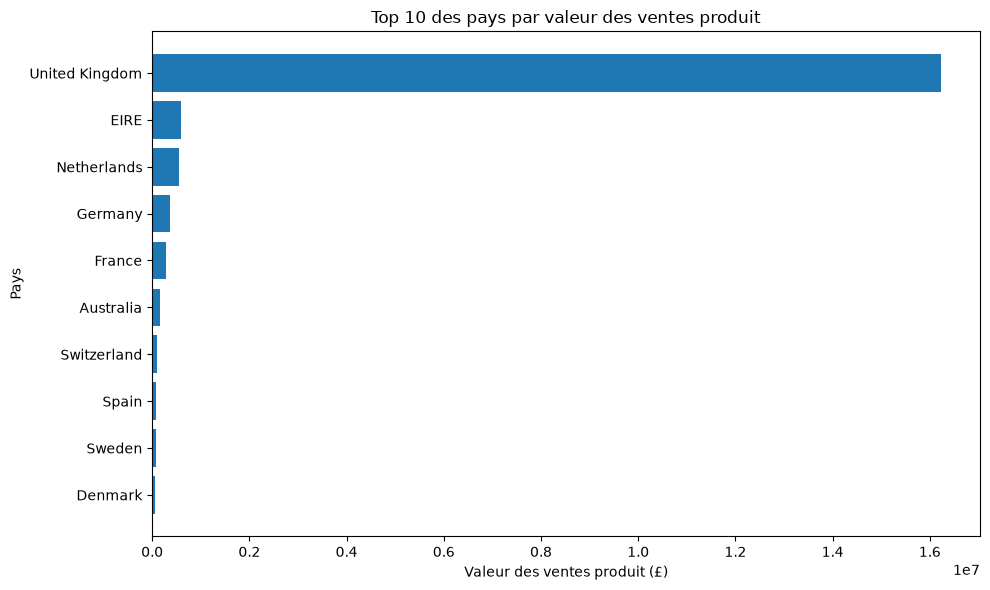

In [14]:
top_countries = country_performance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_countries["country"],
    top_countries["net_product_sales"]
)

plt.title(
    "Top 10 des pays par valeur des ventes produit"
)

plt.xlabel("Valeur des ventes produit (£)")
plt.ylabel("Pays")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### analyse géographique

- Le Royaume-Uni concentre de très loin la plus grande partie de la valeur des ventes produit.
- Les autres pays représentent des volumes beaucoup plus faibles.
- Les principaux pays hors Royaume-Uni sont notamment :
  - EIRE ;
  - Netherlands ;
  - Germany ;
  - France.
- La performance commerciale est donc fortement concentrée sur le Royaume-Uni.

### Analyse des produits

- Objectif : identifier les produits qui génèrent le plus de valeur de ventes.
- L'analyse porte uniquement sur les ventes produit définies
- Les produits sont identifiés par leur `StockCode`.
- La description utilisée provient de `dim_products`.

In [15]:
product_performance = connection.sql(
    """
    SELECT
        f.StockCode AS stock_code,
        d.product_description,

        SUM(
            CASE
                WHEN f.is_product_sale
                THEN f.Quantity
                ELSE 0
            END
        ) AS quantity_sold,

        ROUND(
            SUM(f.gross_product_sales_value),
            2
        ) AS gross_product_sales,

        ROUND(
            SUM(f.net_product_sales_value),
            2
        ) AS net_product_sales

    FROM fact_order_lines AS f

    LEFT JOIN dim_products AS d
        ON f.StockCode = d.stock_code

    WHERE f.line_category = 'product'

    GROUP BY
        f.StockCode,
        d.product_description

    HAVING SUM(f.net_product_sales_value) > 0

    ORDER BY net_product_sales DESC
    """
).df()

display(product_performance.head(15))

,stock_code,product_description,quantity_sold,gross_product_sales,net_product_sales
0,22423,REGENCY CAKESTAND 3 TIER,26519.0,331084.27,314513.47
1,85123A,CREAM HANGING HEART T-LIGHT HOLDER,94323.0,258065.91,248678.81
2,85099B,JUMBO BAG RED RETROSPOT,96931.0,180888.03,178719.21
3,47566,PARTY BUNTING,28216.0,148395.98,147157.43
4,84879,ASSORTED COLOUR BIRD ORNAMENT,80293.0,129681.08,128907.01
5,22086,PAPER CHAIN KIT 50'S CHRISTMAS,35126.0,117884.19,116422.49
6,79321,CHILLI LIGHTS,15918.0,80873.23,80237.48
7,22197,POPCORN HOLDER,88537.0,79552.50,78935.92
8,22386,JUMBO BAG PINK POLKADOT,39467.0,76385.20,75518.22
9,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,31433.0,71361.60,71031.15


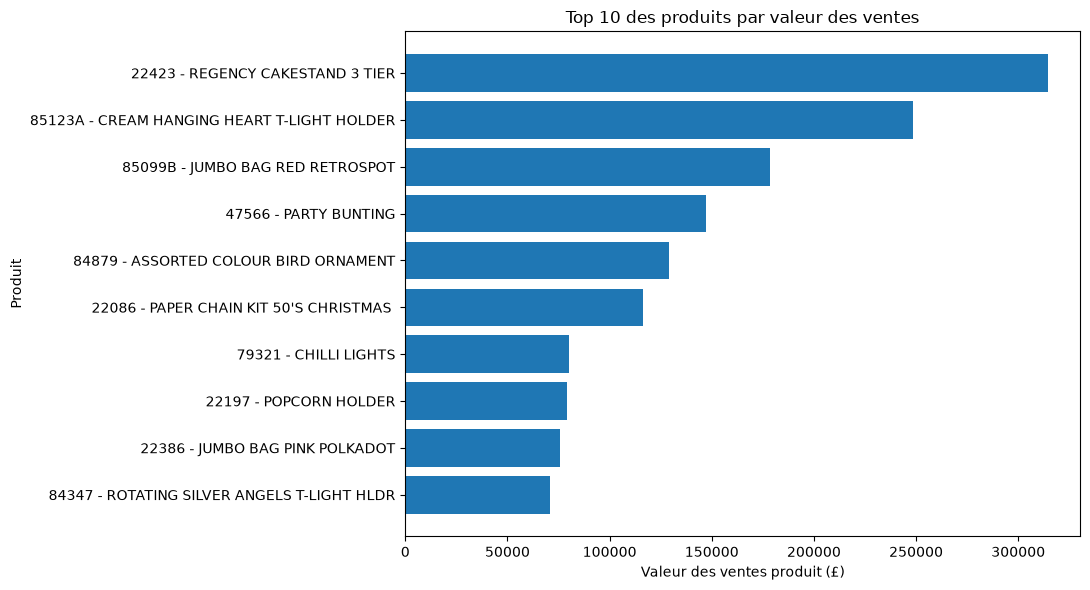

In [16]:
top_products = product_performance.head(10).copy()

top_products["label"] = (
    top_products["stock_code"].astype(str)
    + " - "
    + top_products["product_description"].fillna("Description manquante")
)

plt.figure(figsize=(11, 6))

plt.barh(
    top_products["label"],
    top_products["net_product_sales"]
)

plt.title(
    "Top 10 des produits par valeur des ventes"
)

plt.xlabel("Valeur des ventes produit (£)")
plt.ylabel("Produit")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()


- Le produit REGENCY CAKESTAND 3 TIER génère la valeur de ventes la plus élevée.
- Il est suivi notamment par :
  - CREAM HANGING HEART T-LIGHT HOLDER ;
  - JUMBO BAG RED RETROSPOT ;
  - PARTY BUNTING.

- La concentration des ventes est donc moins extrême au niveau produit qu'au niveau géographique.
- Le classement est basé sur la valeur des ventes produit.
- Les descriptions utilisées proviennent de la description représentative retenue dans dim_products.

### Distribution des montants de commande

- Objectif : comprendre comment se répartissent les montants des commandes.
- Identifier si la majorité des commandes sont de faible ou de forte valeur.
- Repérer la présence éventuelle de commandes exceptionnellement élevées.

In [17]:
order_values = connection.sql(
    """
    SELECT
        Invoice,
        gross_product_sales_value
    FROM fact_orders
    WHERE has_product_sale = TRUE
      AND gross_product_sales_value > 0
    """
).df()

display(order_values.describe())

,gross_product_sales_value
count,39516.000000
mean,498.556394
std,1460.440047
min,0.190000
25%,151.300000
50%,301.800000
75%,486.625000
max,168469.600000


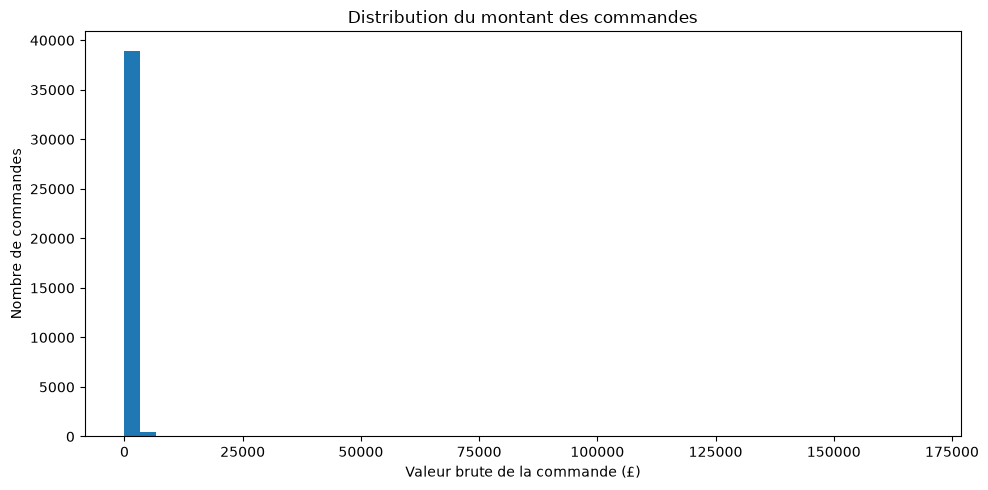

In [18]:
plt.figure(figsize=(10, 5))

plt.hist(
    order_values["gross_product_sales_value"],
    bins=50
)

plt.title(
    "Distribution du montant des commandes"
)

plt.xlabel("Valeur brute de la commande (£)")
plt.ylabel("Nombre de commandes")

plt.tight_layout()

plt.show()

In [19]:
# Seuil du 99e percentile uniquement pour la visualisation

p99 = order_values[
    "gross_product_sales_value"
].quantile(0.99)

print(
    "99e percentile :",
    round(p99, 2),
    "£"
)

99e percentile : 4103.92 £


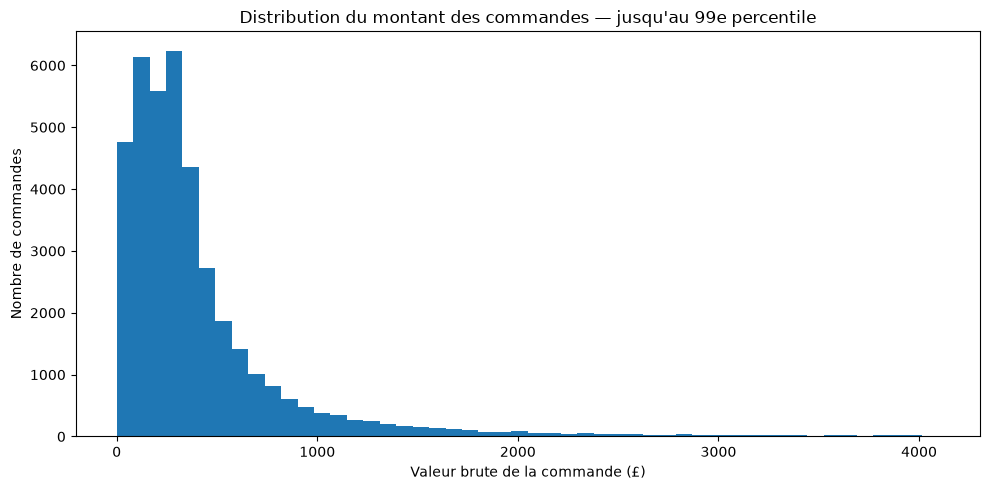

In [20]:
# Distribution zoomée sur 99 % des commandes

order_values_zoom = order_values[
    order_values["gross_product_sales_value"] <= p99
]

plt.figure(figsize=(10, 5))

plt.hist(
    order_values_zoom["gross_product_sales_value"],
    bins=50
)

plt.title(
    "Distribution du montant des commandes — jusqu'au 99e percentile"
)

plt.xlabel("Valeur brute de la commande (£)")
plt.ylabel("Nombre de commandes")

plt.tight_layout()

plt.show()

## Comparaison 2010 vs 2011

- Objectif : comparer l'évolution de l'activité entre 2010 et 2011.
- La comparaison porte uniquement sur janvier à novembre.
- Décembre 2011 est exclu car le dataset s'arrête au 9 décembre 2011.
- Décembre 2010 est également exclu afin de comparer des périodes équivalentes.
- Indicateurs comparés :
  - valeur brute des ventes produit ;
  - annulations produit ;
  - valeur nette des ventes produit ;
  - nombre de commandes ;
  - nombre de clients actifs identifiés ;
  - panier moyen.

In [21]:
year_comparison = connection.sql(
    """
    SELECT
        CAST(
            EXTRACT(YEAR FROM order_datetime)
            AS INTEGER
        ) AS year,

        ROUND(
            SUM(gross_product_sales_value),
            2
        ) AS gross_product_sales,

        ROUND(
            SUM(product_cancellation_value),
            2
        ) AS product_cancellations,

        ROUND(
            SUM(net_product_sales_value),
            2
        ) AS net_product_sales,

        SUM(
            CASE
                WHEN has_product_sale THEN 1
                ELSE 0
            END
        ) AS purchase_invoices,

        COUNT(
            DISTINCT CASE
                WHEN has_product_sale
                    AND customer_id IS NOT NULL
                THEN customer_id
            END
        ) AS active_identified_customers,

        ROUND(
            SUM(gross_product_sales_value)
            /
            NULLIF(
                SUM(
                    CASE
                        WHEN has_product_sale THEN 1
                        ELSE 0
                    END
                ),
                0
            ),
            2
        ) AS average_order_value

    FROM fact_orders

    WHERE EXTRACT(YEAR FROM order_datetime) IN (2010, 2011)
      AND EXTRACT(MONTH FROM order_datetime) <= 11

    GROUP BY 1

    ORDER BY 1
    """
).df()

display(year_comparison)

,year,gross_product_sales,product_cancellations,net_product_sales,purchase_invoices,active_identified_customers,average_order_value
0,2010,8628418.42,-221407.48,8407010.94,18077.0,4127,477.31
1,2011,8878008.02,-286989.56,8591018.46,17407.0,4168,510.03


In [22]:
comparison_change = pd.DataFrame({
    "KPI": [
        "Net product sales",
        "Purchase invoices",
        "Active identified customers",
        "Average order value"
    ],

    "2010": [
        year_comparison.loc[
            year_comparison["year"] == 2010,
            "net_product_sales"
        ].iloc[0],

        year_comparison.loc[
            year_comparison["year"] == 2010,
            "purchase_invoices"
        ].iloc[0],

        year_comparison.loc[
            year_comparison["year"] == 2010,
            "active_identified_customers"
        ].iloc[0],

        year_comparison.loc[
            year_comparison["year"] == 2010,
            "average_order_value"
        ].iloc[0]
    ],

    "2011": [
        year_comparison.loc[
            year_comparison["year"] == 2011,
            "net_product_sales"
        ].iloc[0],

        year_comparison.loc[
            year_comparison["year"] == 2011,
            "purchase_invoices"
        ].iloc[0],

        year_comparison.loc[
            year_comparison["year"] == 2011,
            "active_identified_customers"
        ].iloc[0],

        year_comparison.loc[
            year_comparison["year"] == 2011,
            "average_order_value"
        ].iloc[0]
    ]
})

comparison_change["change_pct"] = (
    (
        comparison_change["2011"]
        / comparison_change["2010"]
    )
    - 1
) * 100

comparison_change["change_pct"] = (
    comparison_change["change_pct"].round(2)
)

display(comparison_change)

,KPI,2010,2011,change_pct
0,Net product sales,8407010.94,8591018.46,2.19
1,Purchase invoices,18077.00,17407.00,-3.71
2,Active identified customers,4127.00,4168.00,0.99
3,Average order value,477.31,510.03,6.86


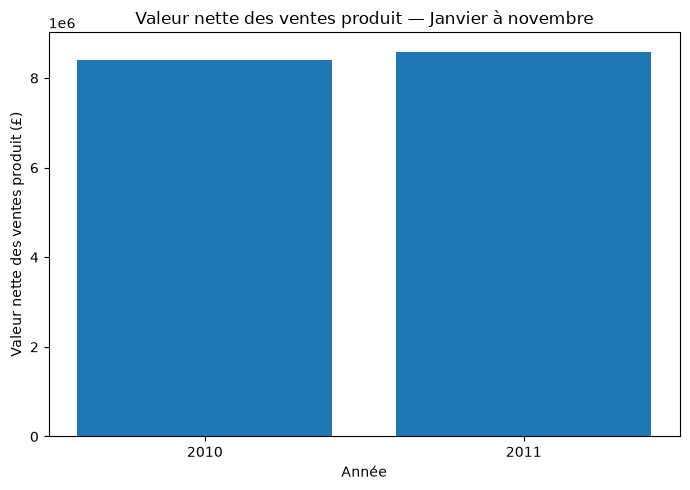

In [ ]:
plt.figure(figsize=(7, 5))

plt.bar(
    year_comparison["year"].astype(str),
    year_comparison["net_product_sales"]
)

plt.title(
    "Valeur nette des ventes produit Janvier à novembre"
)

plt.xlabel("Année")
plt.ylabel("Valeur nette des ventes produit (£)")

plt.tight_layout()

plt.show()

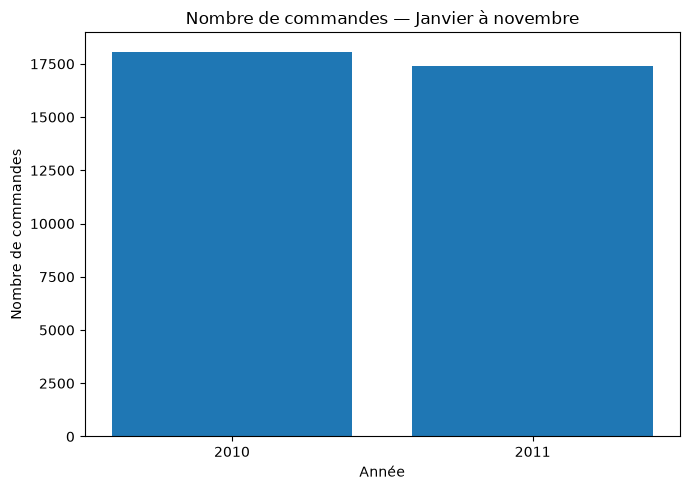

In [ ]:
plt.figure(figsize=(7, 5))

plt.bar(
    year_comparison["year"].astype(str),
    year_comparison["purchase_invoices"]
)

plt.title(
    "Nombre de commandes  Janvier à novembre"
)

plt.xlabel("Année")
plt.ylabel("Nombre de commandes")

plt.tight_layout()

plt.show()

### comparaison 2010 vs 2011

- La comparaison porte sur janvier à novembre pour les deux années.
- La valeur nette des ventes produit progresse de 2,19 % en 2011.
- Le nombre de commandes diminue pourtant de 3,71 %.
- Le nombre de clients actifs identifiés reste presque stable avec une hausse de 0,99 %.
- Le panier moyen progresse nettement de 6,86 % :
  - 2010 : environ £477
  - 2011 : environ £510
- La hausse des ventes en 2011 ne vient donc pas d'un plus grand nombre de commandes.
- Elle semble principalement portée par une valeur moyenne de commande plus élevée.
- La valeur des annulations est également plus importante en 2011 et sera analysée plus loin.

## Analyse par jour de la semaine

- Objectif : identifier les jours où l'activité commerciale est la plus importante.
- Indicateurs étudiés :
  - valeur des ventes produit ;
  - nombre de commandes ;
  - panier moyen.
- L'analyse permet d'identifier d'éventuelles différences d'activité selon le jour de la semaine.

In [25]:
weekday_performance = connection.sql(
    """
    SELECT
        EXTRACT(
            'isodow'
            FROM order_datetime
        ) AS weekday_number,

        DAYNAME(order_datetime) AS weekday,

        ROUND(
            SUM(net_product_sales_value),
            2
        ) AS net_product_sales,

        SUM(
            CASE
                WHEN has_product_sale THEN 1
                ELSE 0
            END
        ) AS purchase_invoices,

        ROUND(
            SUM(gross_product_sales_value)
            /
            NULLIF(
                SUM(
                    CASE
                        WHEN has_product_sale THEN 1
                        ELSE 0
                    END
                ),
                0
            ),
            2
        ) AS average_order_value

    FROM fact_orders

    GROUP BY
        weekday_number,
        weekday

    ORDER BY weekday_number
    """
).df()

display(weekday_performance)

,weekday_number,weekday,net_product_sales,purchase_invoices,average_order_value
0,1,Monday,3324521.95,6245.0,548.37
1,2,Tuesday,3699815.64,7147.0,544.04
2,3,Wednesday,3310254.87,7115.0,475.66
3,4,Thursday,3915234.69,8167.0,492.23
4,5,Friday,2937814.36,5988.0,529.84
5,6,Saturday,9803.05,30.0,326.77
6,7,Sunday,1783816.95,4824.0,373.40


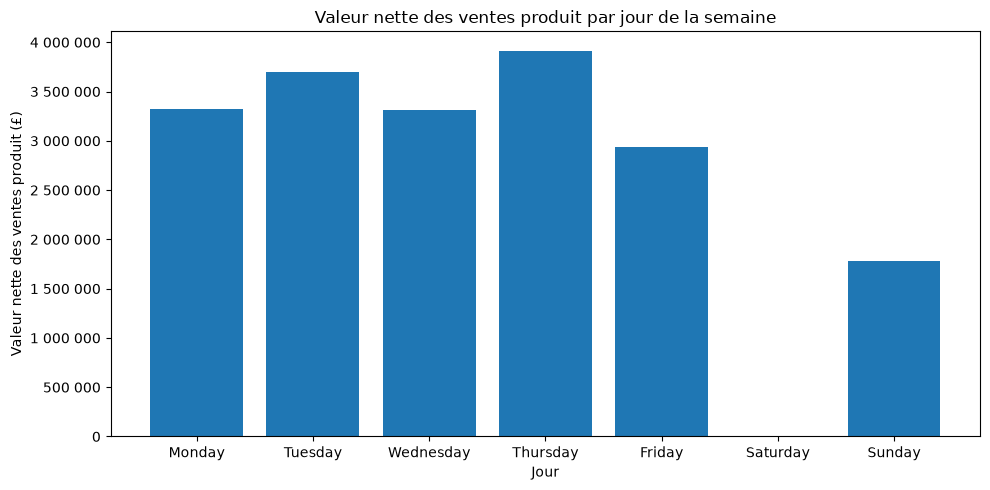

In [28]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10, 5))

plt.bar(
    weekday_performance["weekday"],
    weekday_performance["net_product_sales"]
)

plt.title(
    "Valeur nette des ventes produit par jour de la semaine"
)

plt.xlabel("Jour")
plt.ylabel("Valeur nette des ventes produit (£)")

# Affichage des vraies valeurs
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"{x:,.0f}".replace(",", " ")
    )
)

plt.tight_layout()

plt.show()

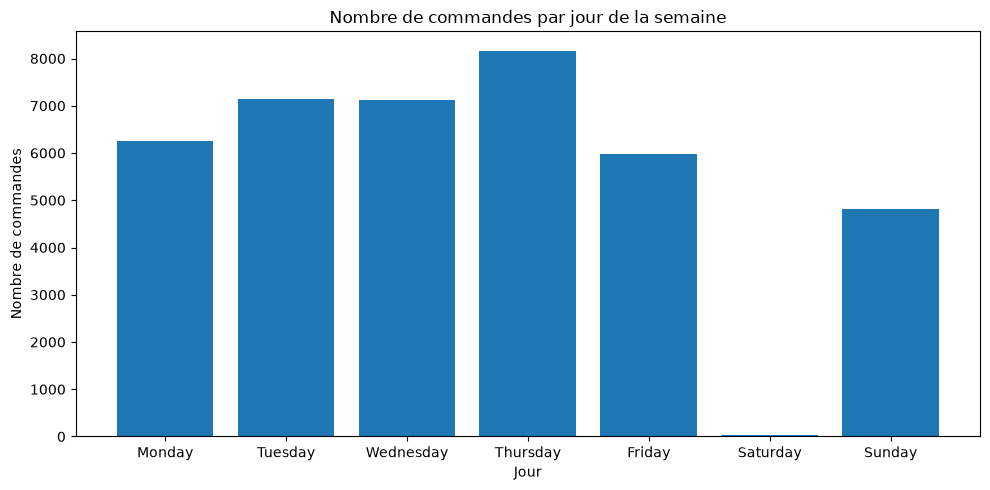

In [27]:
plt.figure(figsize=(10, 5))

plt.bar(
    weekday_performance["weekday"],
    weekday_performance["purchase_invoices"]
)

plt.title(
    "Nombre de commandes par jour de la semaine"
)

plt.xlabel("Jour")
plt.ylabel("Nombre de commandes")

plt.tight_layout()

plt.show()

### jour de la semaine

- L'activité commerciale varie sensiblement selon le jour de la semaine.
- Le jeudi présente le nombre de commandes le plus élevé.
- Le jeudi présente également la valeur nette des ventes produit la plus importante.
- Le mardi et le mercredi font aussi partie des journées les plus actives.
- Le vendredi présente un niveau d'activité inférieur à celui du milieu de semaine.
- Le dimanche enregistre une activité significative mais inférieure aux principaux jours de semaine.
- L'activité observée le samedi est quasi inexistante dans le dataset.
- Les variations de ventes par jour semblent globalement cohérentes avec les variations du nombre de commandes.

In [29]:
saturday_check = connection.sql(
    """
    SELECT
        COUNT(*) AS invoices,
        
        SUM(
            CASE
                WHEN has_product_sale THEN 1
                ELSE 0
            END
        ) AS purchase_invoices,

        ROUND(
            SUM(gross_product_sales_value),
            2
        ) AS gross_product_sales,

        MIN(order_datetime) AS first_saturday,
        MAX(order_datetime) AS last_saturday

    FROM fact_orders

    WHERE EXTRACT(
        'isodow'
        FROM order_datetime
    ) = 6
    """
).df()

display(saturday_check)

,invoices,purchase_invoices,gross_product_sales,first_saturday,last_saturday
0,32,30.0,9803.05,2009-12-05 10:11:00,2009-12-05 16:01:00


In [30]:
saturday_orders = connection.sql(
    """
    SELECT
        Invoice,
        order_datetime,
        customer_id,
        country,
        gross_product_sales_value,
        net_product_sales_value,
        has_product_sale,
        is_cancellation
    FROM fact_orders

    WHERE EXTRACT(
        'isodow'
        FROM order_datetime
    ) = 6

    ORDER BY order_datetime
    """
).df()

display(saturday_orders)

,Invoice,order_datetime,customer_id,country,gross_product_sales_value,net_product_sales_value,has_product_sale,is_cancellation
0,490363,2009-12-05 10:11:00,13199,United Kingdom,138.24,138.24,True,False
1,490364,2009-12-05 10:25:00,13487,United Kingdom,103.95,103.95,True,False
2,490365,2009-12-05 10:27:00,17018,United Kingdom,351.60,351.60,True,False
3,490366,2009-12-05 10:31:00,18071,United Kingdom,227.25,227.25,True,False
4,490367,2009-12-05 10:44:00,16593,United Kingdom,79.60,79.60,True,False
5,490368,2009-12-05 10:58:00,14238,United Kingdom,159.10,159.10,True,False
6,490369,2009-12-05 11:19:00,15223,United Kingdom,230.20,230.20,True,False
7,490370,2009-12-05 12:01:00,17593,United Kingdom,452.95,452.95,True,False
8,490371,2009-12-05 12:02:00,13021,United Kingdom,233.71,233.71,True,False
9,490372,2009-12-05 12:13:00,17115,United Kingdom,434.15,434.15,True,False


## Analyse des annulations

- Objectif : mesurer l'importance des annulations 
- Deux indicateurs sont étudiés :
  - le nombre de factures d'annulation produit 
  - la valeur des annulations par rapport aux ventes produit.
- Une facture préfixée par C est considérée comme une annulation selon la documentation du dataset.
- Décembre 2011 est un mois incomplet car le dataset s'arrête au 9 décembre.

In [31]:
monthly_cancellations = connection.sql(
    """
    SELECT
        DATE_TRUNC(
            'month',
            order_datetime
        ) AS month,

        SUM(
            CASE
                WHEN has_product_sale THEN 1
                ELSE 0
            END
        ) AS purchase_invoices,

        SUM(
            CASE
                WHEN has_product_cancellation THEN 1
                ELSE 0
            END
        ) AS cancellation_invoices,

        ROUND(
            SUM(gross_product_sales_value),
            2
        ) AS gross_product_sales,

        ROUND(
            ABS(SUM(product_cancellation_value)),
            2
        ) AS cancellation_value

    FROM fact_orders

    GROUP BY 1
    ORDER BY 1
    """
).df()


monthly_cancellations["cancellation_invoice_ratio_pct"] = (
    monthly_cancellations["cancellation_invoices"]
    / monthly_cancellations["purchase_invoices"]
    * 100
)

monthly_cancellations["cancellation_value_ratio_pct"] = (
    monthly_cancellations["cancellation_value"]
    / monthly_cancellations["gross_product_sales"]
    * 100
)

display(monthly_cancellations)

,month,purchase_invoices,cancellation_invoices,gross_product_sales,cancellation_value,cancellation_invoice_ratio_pct,cancellation_value_ratio_pct
0,2009-12-01,1666.0,379.0,801102.97,19561.28,22.749100,2.441793
1,2010-01-01,1049.0,241.0,613850.81,7465.63,22.974261,1.216196
2,2010-02-01,1189.0,219.0,539744.69,12584.39,18.418839,2.331545
3,2010-03-01,1647.0,351.0,764333.85,9657.20,21.311475,1.263479
4,2010-04-01,1435.0,263.0,648993.82,10025.26,18.327526,1.544739
5,2010-05-01,1484.0,387.0,645645.39,37294.14,26.078167,5.776257
6,2010-06-01,1612.0,319.0,699316.02,26380.61,19.789082,3.772345
7,2010-07-01,1507.0,314.0,634896.99,17132.73,20.836098,2.698505
8,2010-08-01,1402.0,242.0,676060.72,12418.65,17.261056,1.836913
9,2010-09-01,1789.0,319.0,871878.34,27777.97,17.831191,3.185992


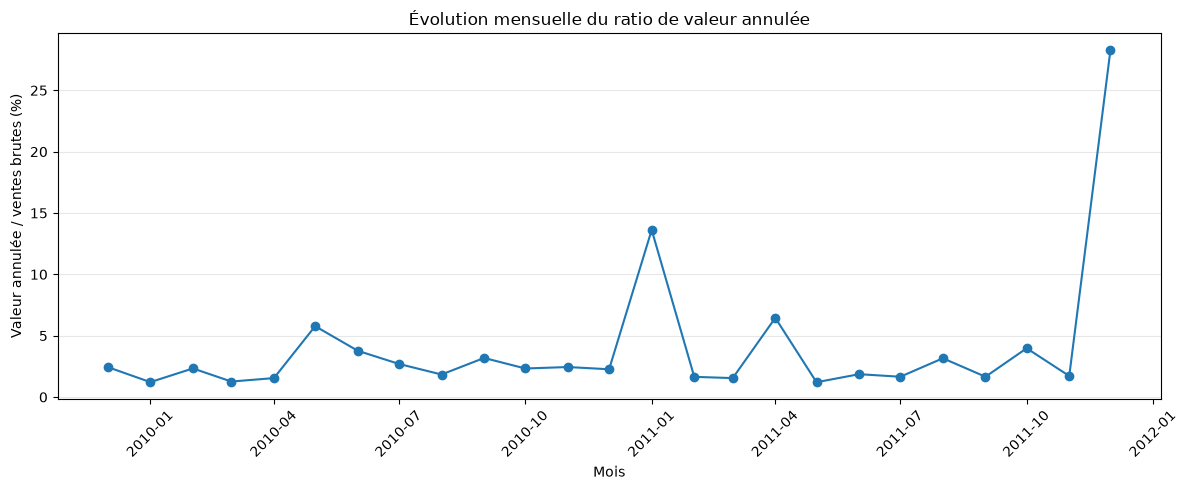

In [ ]:
#  Graphique 
#  ratio de valeur annulée
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_cancellations["month"],
    monthly_cancellations["cancellation_value_ratio_pct"],
    marker="o"
)

plt.title(
    "Évolution mensuelle du ratio de valeur annulée"
)

plt.xlabel("Mois")
plt.ylabel("Valeur annulée / ventes brutes (%)")

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

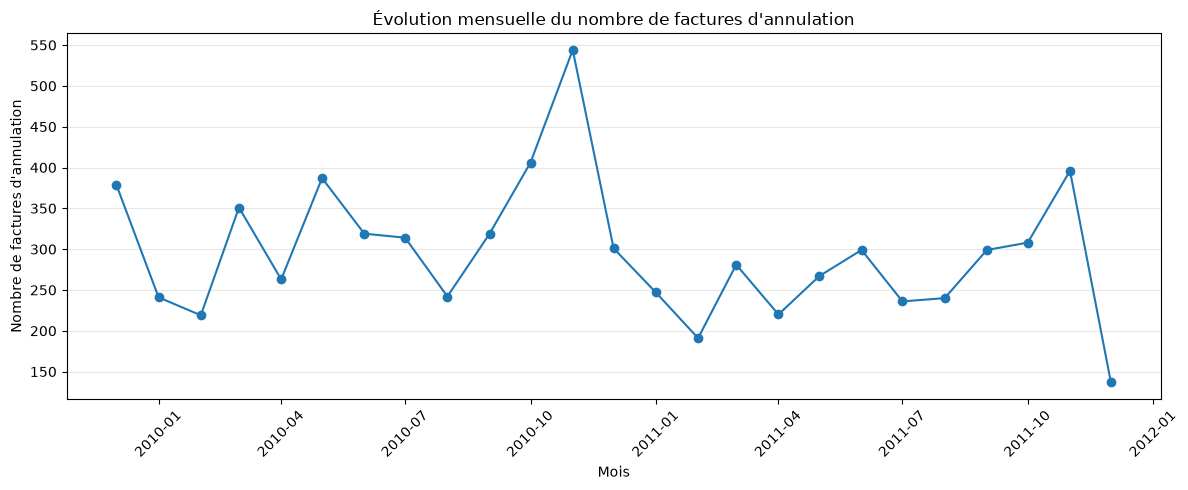

In [33]:
# Graphique  nombre de factures d’annulation
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_cancellations["month"],
    monthly_cancellations["cancellation_invoices"],
    marker="o"
)

plt.title(
    "Évolution mensuelle du nombre de factures d'annulation"
)

plt.xlabel("Mois")
plt.ylabel("Nombre de factures d'annulation")

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()

### annulations mensuelles

- Le nombre de factures d'annulation varie selon les mois.
- Le niveau le plus élevé est observé autour de novembre 2010, avec plus de 500 factures d'annulation.
- Des niveaux relativement élevés apparaissent également à l'automne 2010 et à l'automne 2011.
- Le nombre brut d'annulations doit être interprété avec le niveau global d'activité : un mois avec davantage de commandes peut naturellement générer davantage d'annulations.
- Le ratio de valeur annulée est généralement relativement faible, souvent inférieur à environ 5 % des ventes brutes produit.
- Certains mois se distinguent cependant par un ratio nettement plus élevé :
  - autour de janvier 2011 ;
  - autour d'avril 2011 ;
  - ponctuellement en 2010.
- Le très fort ratio observé en décembre 2011 doit être interprété avec prudence.
- Le dataset s'arrête au 9 décembre 2011 : les ventes du mois sont donc incomplètes et le ratio mensuel n'est pas directement comparable aux mois complets.
- Il est donc plus pertinent d'analyser à la fois :
  - le nombre d'annulations 
  - leur poids financier par rapport aux ventes.

### Annulations par produit

- Objectif : identifier les produits associés aux montants d'annulation les plus importants.
- L'analyse porte sur les lignes identifiées comme annulations produit.
- Les annulations sont mesurées :
  - en nombre de factures d'annulation 
  - en quantité annulée 
  - en valeur annulée


Quels produits représentent le plus gros impact financier parmi les annulations ?

In [34]:
product_cancellations = connection.sql(
    """
    SELECT
        f.StockCode AS stock_code,
        d.product_description,

        COUNT(
            DISTINCT f.Invoice
        ) AS cancellation_invoices,

        ABS(
            SUM(f.Quantity)
        ) AS cancelled_quantity,

        ROUND(
            ABS(
                SUM(f.product_cancellation_value)
            ),
            2
        ) AS cancellation_value

    FROM fact_order_lines AS f

    LEFT JOIN dim_products AS d
        ON f.StockCode = d.stock_code

    WHERE f.is_product_cancellation = TRUE

    GROUP BY
        f.StockCode,
        d.product_description

    ORDER BY cancellation_value DESC
    """
).df()

display(product_cancellations.head(15))

,stock_code,product_description,cancellation_invoices,cancelled_quantity,cancellation_value
0,23843,"PAPER CRAFT , LITTLE BIRDIE",1,80995.0,168469.60
1,23166,MEDIUM CERAMIC TOP STORAGE JAR,10,74494.0,77479.64
2,22423,REGENCY CAKESTAND 3 TIER,341,1452.0,16570.80
3,85123A,CREAM HANGING HEART T-LIGHT HOLDER,134,3637.0,9387.10
4,71477,COLOURED GLASS STAR T-LIGHT HOLDER,67,2574.0,7164.12
5,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,4,3159.0,6614.37
6,79323W,"Unsaleable, destroyed.",124,1088.0,6421.10
7,21843,RED RETROSPOT CAKE STAND,154,587.0,5270.25
8,84078A,SET/4 WHITE RETRO STORAGE CUBES,20,147.0,5187.65
9,23113,PANTRY CHOPPING BOARD,6,946.0,4803.06


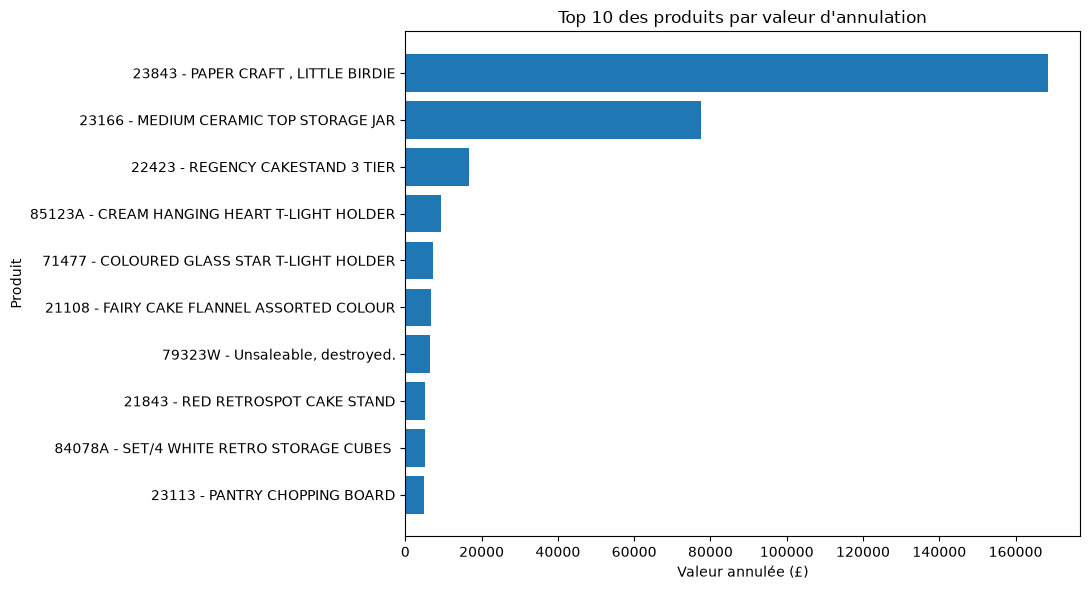

In [35]:
top_cancelled_products = (
    product_cancellations
    .head(10)
    .copy()
)

top_cancelled_products["label"] = (
    top_cancelled_products["stock_code"].astype(str)
    + " - "
    + top_cancelled_products[
        "product_description"
    ].fillna("Description manquante")
)

plt.figure(figsize=(11, 6))

plt.barh(
    top_cancelled_products["label"],
    top_cancelled_products["cancellation_value"]
)

plt.title(
    "Top 10 des produits par valeur d'annulation"
)

plt.xlabel("Valeur annulée (£)")
plt.ylabel("Produit")

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

### Lecture des annulations par produit

- La valeur des annulations est fortement concentrée sur quelques références.
- 23843 - PAPER CRAFT , LITTLE BIRDIE présente de très loin la valeur annulée la plus élevée.
- Cette référence correspond à un mouvement exceptionnel déjà identifié lors de l'audit des données.
- Une quantité de 80 995 unités a été enregistrée puis annulée quelques minutes plus tard.
- Ce cas exerce donc une forte influence sur le classement des produits par valeur d'annulation.
- 23166 - MEDIUM CERAMIC TOP STORAGE JAR présente également une valeur d'annulation particulièrement élevée.
- Les autres références présentent des montants nettement inférieurs.
- Une valeur d'annulation élevée ne signifie pas nécessairement un grand nombre d'annulations :
  - elle peut résulter de quelques annulations de très grande valeur ;
  - ou de nombreuses annulations de faible valeur.


## Taille des commandes

- Objectif : comprendre la composition des commandes.
- Deux dimensions sont étudiées :
  - le nombre de références différentes par commande ;
  - la quantité totale de produits vendus.
- Distinguer les petites commandes des commandes contenant de nombreux produits.


In [36]:
order_size = connection.sql(
    """
    SELECT
        Invoice,

        distinct_stockcodes,

        product_sale_quantity,

        gross_product_sales_value

    FROM fact_orders

    WHERE has_product_sale = TRUE
      AND gross_product_sales_value > 0
    """
).df()

display(
    order_size[
        [
            "distinct_stockcodes",
            "product_sale_quantity",
            "gross_product_sales_value"
        ]
    ].describe()
)

,distinct_stockcodes,product_sale_quantity,gross_product_sales_value
count,39516.000000,39516.000000,39516.000000
mean,25.206954,283.985145,498.556394
std,42.384305,1204.166679,1460.440047
min,1.000000,1.000000,0.190000
25%,6.000000,68.000000,151.300000
50%,15.000000,149.000000,301.800000
75%,29.000000,290.000000,486.625000
max,1110.000000,87167.000000,168469.600000


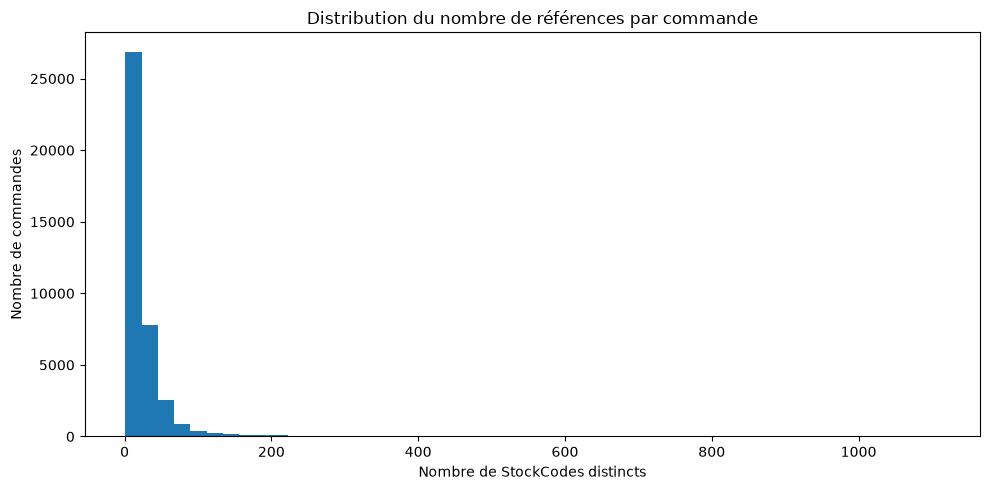

In [37]:
plt.figure(figsize=(10, 5))

plt.hist(
    order_size["distinct_stockcodes"],
    bins=50
)

plt.title(
    "Distribution du nombre de références par commande"
)

plt.xlabel("Nombre de StockCodes distincts")
plt.ylabel("Nombre de commandes")

plt.tight_layout()

plt.show()

### Taille des commandes

- La majorité des commandes contient un nombre relativement limité de références différentes.
- La distribution est fortement asymétrique
- Quelques commandes contiennent un nombre exceptionnellement élevé de références.


In [38]:
# 99e percentile du nombre de références par commande

p99_stockcodes = order_size[
    "distinct_stockcodes"
].quantile(0.99)

print(
    "99e percentile :",
    round(p99_stockcodes, 0),
    "références"
)

99e percentile : 198.0 références


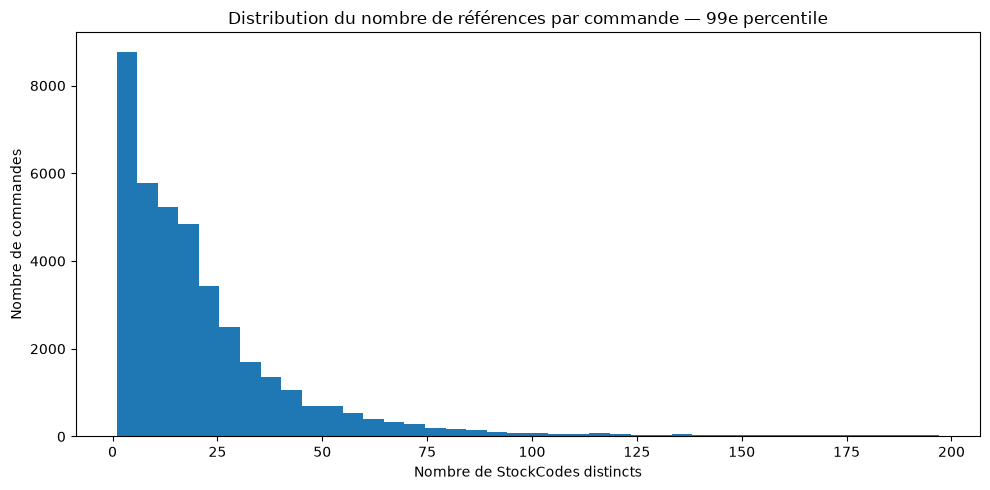

In [39]:
# Distribution zoomée sur 99 % des commandes

order_size_zoom = order_size[
    order_size["distinct_stockcodes"] <= p99_stockcodes
]

plt.figure(figsize=(10, 5))

plt.hist(
    order_size_zoom["distinct_stockcodes"],
    bins=40
)

plt.title(
    "Distribution du nombre de références par commande — 99e percentile"
)

plt.xlabel("Nombre de StockCodes distincts")
plt.ylabel("Nombre de commandes")

plt.tight_layout()

plt.show()


- La distribution du nombre de références par commande est fortement asymétrique
- La majorité des commandes contient relativement peu de références différentes.
- Le 99e percentile est de 198 références.
- Cela signifie que 99 % des commandes contiennent au maximum 198 références distinctes.
- Quelques commandes exceptionnellement grandes expliquent la longue traîne de la distribution.


## Fréquence d'achat des clients

- Objectif : comprendre combien de fois les clients identifiés achètent.
- L'analyse porte uniquement sur les clients disposant d'un `Customer ID`.


In [40]:
customer_frequency = connection.sql(
    """
    SELECT
        customer_id,

        SUM(
            CASE
                WHEN has_product_sale THEN 1
                ELSE 0
            END
        ) AS purchase_count

    FROM fact_orders

    WHERE customer_id IS NOT NULL

    GROUP BY customer_id

    HAVING purchase_count > 0

    ORDER BY purchase_count DESC
    """
).df()

display(customer_frequency.describe())

,customer_id,purchase_count
count,5852.000000,5852.000000
mean,15319.707109,6.253247
std,1714.929942,12.749286
min,12346.000000,1.000000
25%,13837.750000,1.000000
50%,15320.500000,3.000000
75%,16802.250000,7.000000
max,18287.000000,373.000000


In [41]:
def frequency_group(x):
    if x == 1:
        return "1 commande"
    elif x == 2:
        return "2 commandes"
    elif x <= 5:
        return "3 à 5 commandes"
    elif x <= 10:
        return "6 à 10 commandes"
    else:
        return "Plus de 10 commandes"


customer_frequency["frequency_group"] = (
    customer_frequency["purchase_count"]
    .apply(frequency_group)
)

frequency_distribution = (
    customer_frequency["frequency_group"]
    .value_counts()
    .reindex([
        "1 commande",
        "2 commandes",
        "3 à 5 commandes",
        "6 à 10 commandes",
        "Plus de 10 commandes"
    ])
    .reset_index()
)

frequency_distribution.columns = [
    "frequency_group",
    "customers"
]

display(frequency_distribution)

,frequency_group,customers
0,1 commande,1618
1,2 commandes,945
2,3 à 5 commandes,1503
3,6 à 10 commandes,922
4,Plus de 10 commandes,864


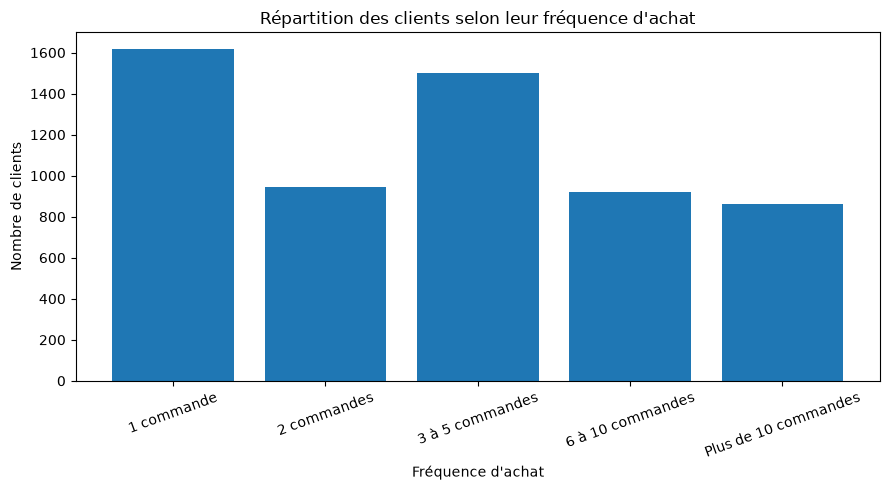

In [42]:
plt.figure(figsize=(9, 5))

plt.bar(
    frequency_distribution["frequency_group"],
    frequency_distribution["customers"]
)

plt.title(
    "Répartition des clients selon leur fréquence d'achat"
)

plt.xlabel("Fréquence d'achat")
plt.ylabel("Nombre de clients")

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

### La fréquence d'achat

- 5 852 clients identifiés ont réalisé au moins une commande produit.
- La fréquence médiane est de 3 commandes par client.
- La fréquence moyenne est plus élevée, avec environ 6,25 commandes par client.
- Cette différence entre moyenne et médiane indique la présence de clients particulièrement fréquents.
- La fréquence maximale observée atteint 373 commandes pour un même client.
- Répartition des clients :
  - **1 commande : 1 618 clients** (27,7 %) ;
  - **2 commandes : 945 clients** (16,1 %) ;
  - **3 à 5 commandes : 1 503 clients** (25,7 %) ;
  - **6 à 10 commandes : 922 clients** (15,8 %) ;
  - **plus de 10 commandes : 864 clients** (14,8 %).
- Une part importante de la clientèle est donc occasionnelle.
- Cependant, un groupe de clients présente une fréquence d'achat élevée.
- Cette hétérogénéité justifie l'utilisation future d'une segmentation RFM.

Quelle proportion des clients génère quelle proportion de la valeur des ventes ?

## Concentration de la valeur des ventes par client

- Objectif : mesurer la concentration de la valeur générée par les clients.
- Les clients sont classés du plus fort au plus faible niveau de ventes.
- On calcule ensuite :
  - la part cumulée des clients 
  - la part cumulée de la valeur nette des ventes produit.
- Cette analyse permet de déterminer si une petite proportion de clients concentre une part importante de la valeur.


In [43]:
# Ventes par client

customer_value = connection.sql(
    """
    SELECT
        customer_id,

        ROUND(
            SUM(net_product_sales_value),
            2
        ) AS net_product_sales

    FROM fact_orders

    WHERE customer_id IS NOT NULL

    GROUP BY customer_id

    HAVING SUM(net_product_sales_value) > 0

    ORDER BY net_product_sales DESC
    """
).df()

display(customer_value.head(10))

,customer_id,net_product_sales
0,18102,578408.64
1,14646,523202.74
2,14156,297961.56
3,14911,258601.47
4,17450,233803.91
5,13694,190354.06
6,17511,168504.44
7,12415,143107.02
8,16684,141530.29
9,15061,124982.13


In [44]:
# Pareto
customer_value = (
    customer_value
    .sort_values(
        "net_product_sales",
        ascending=False
    )
    .reset_index(drop=True)
)

customer_value["cumulative_sales"] = (
    customer_value["net_product_sales"]
    .cumsum()
)

customer_value["cumulative_sales_pct"] = (
    customer_value["cumulative_sales"]
    / customer_value["net_product_sales"].sum()
    * 100
)

customer_value["cumulative_customers_pct"] = (
    (customer_value.index + 1)
    / len(customer_value)
    * 100
)

display(customer_value.head(10))

,customer_id,net_product_sales,cumulative_sales,cumulative_sales_pct,cumulative_customers_pct
0,18102,578408.64,578408.64,3.523691,0.017135
1,14646,523202.74,1101611.38,6.711066,0.034270
2,14156,297961.56,1399572.94,8.526261,0.051405
3,14911,258601.47,1658174.41,10.101672,0.068540
4,17450,233803.91,1891978.32,11.526016,0.085675
5,13694,190354.06,2082332.38,12.685662,0.102810
6,17511,168504.44,2250836.82,13.712198,0.119945
7,12415,143107.02,2393943.84,14.584013,0.137080
8,16684,141530.29,2535474.13,15.446221,0.154215
9,15061,124982.13,2660456.26,16.207618,0.171350


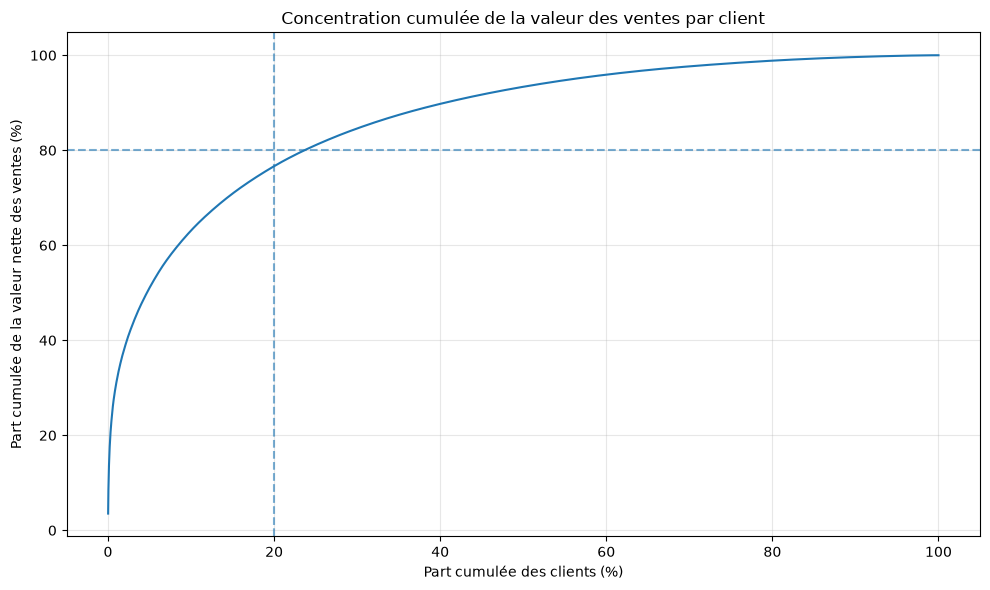

In [45]:
plt.figure(figsize=(10, 6))

plt.plot(
    customer_value["cumulative_customers_pct"],
    customer_value["cumulative_sales_pct"]
)

plt.axhline(
    y=80,
    linestyle="--",
    alpha=0.6
)

plt.axvline(
    x=20,
    linestyle="--",
    alpha=0.6
)

plt.title(
    "Concentration cumulée de la valeur des ventes par client"
)

plt.xlabel("Part cumulée des clients (%)")
plt.ylabel("Part cumulée de la valeur nette des ventes (%)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [46]:
for threshold in [1, 5, 10, 20]:
    sales_share = customer_value.loc[
        customer_value[
            "cumulative_customers_pct"
        ] <= threshold,
        "net_product_sales"
    ].sum()

    sales_share_pct = (
        sales_share
        / customer_value["net_product_sales"].sum()
        * 100
    )

    print(
        f"Top {threshold}% des clients : "
        f"{sales_share_pct:.2f}% des ventes"
    )

Top 1% des clients : 30.97% des ventes
Top 5% des clients : 51.00% des ventes
Top 10% des clients : 63.08% des ventes
Top 20% des clients : 76.64% des ventes


In [47]:
# Part exacte des clients nécessaire pour atteindre 80 % des ventes

first_80 = customer_value[
    customer_value["cumulative_sales_pct"] >= 80
].iloc[0]

customers_for_80_pct = first_80[
    "cumulative_customers_pct"
]

print(
    f"Part des clients nécessaire pour atteindre 80 % des ventes : "
    f"{customers_for_80_pct:.2f}%"
)

Part des clients nécessaire pour atteindre 80 % des ventes : 23.66%


### Concentration client

- La valeur des ventes est fortement concentrée sur une minorité de clients.
- Le top **1 % des clients** génère environ **30,97 %** de la valeur nette des ventes.
- Le top **5 %** génère environ **51,00 %** des ventes.
- Le top **10 %** génère environ **63,08 %** des ventes.
- Le top **20 %** génère environ **76,64 %** des ventes.
- Il faut environ **23,66 % des clients** pour atteindre **80 % de la valeur nette des ventes**.
- La règle classique des 80/20 n'est donc pas exactement observée.
- La concentration reste néanmoins très forte.
- Une part relativement réduite de la clientèle représente une part majeure de la valeur générée.
- Ce résultat justifie une segmentation client pour identifier les clients à forte valeur et adapter les actions commerciales.

In [48]:
connection.close()

print("Connexion DuckDB fermée")

Connexion DuckDB fermée
